In [1]:
# Sydney Housing Project - V2.0 Feature Engineering (Spatial)
import pandas as pd
import numpy as np
from clearml import Task

# 1. Initialize ClearML tracker for V2
task = Task.init(project_name="Sydney_Housing_Project", task_name="V2_Feature_Engineering_Distance")

print(" Loading cleaned V1 rental data...")
df = pd.read_csv("nsw_rental_bonds.csv")

# 2. Fetch standard Australian Postcode mapping data directly from an open-source GitHub repo
print(" Fetching Australian Postcode spatial mapping...")
url = "https://raw.githubusercontent.com/matthewproctor/australianpostcodes/master/australian_postcodes.csv"
postcode_df = pd.read_csv(url)

# 3. Filter for NSW postcodes and fix the column name ('long' -> 'lon')
nsw_postcodes = postcode_df[postcode_df['state'] == 'NSW'][['postcode', 'lat', 'long']].drop_duplicates(subset=['postcode'])
nsw_postcodes = nsw_postcodes.rename(columns={'long': 'lon'})

# 4. Merge our rental data with the coordinates based on Postcode
print(" Merging rental data with spatial coordinates...")
df = df.merge(nsw_postcodes, left_on='Postcode', right_on='postcode', how='left')

# 5. The Haversine Formula (Calculates great-circle distance between two points on a sphere)
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0 # Earth radius in kilometers
    dLat = np.radians(lat2 - lat1)
    dLon = np.radians(lon2 - lon1)
    a = np.sin(dLat/2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dLon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

# 6. Calculate distance to Sydney Central Station
print(" Calculating distance to Sydney Central Station (km)...")

# location of sydney central station
central_station_lat, central_station_lon = -33.8832, 151.2069 

# new list Distance_to_Central_km
df['Distance_to_Central_km'] = haversine(df['lat'], df['lon'], central_station_lat, central_station_lon)

# 7. Clean up redundant columns we don't need anymore
df = df.drop(columns=['postcode', 'lat', 'lon'])

print("\n V2.0 Features generated successfully!")
display(df.head())

ClearML Task: created new task id=6d931abab39549a9b3bc60645712a046
2026-04-25 05:01:20,832 - clearml.Task - INFO - Storing jupyter notebook directly as code


2026-04-25 05:01:23.744879: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-25 05:01:23.758715: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777093283.777240    1566 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777093283.782966    1566 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-25 05:01:23.801485: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

ClearML results page: https://app.clear.ml/projects/63f62254946d42f8aae80879eb21f60c/experiments/6d931abab39549a9b3bc60645712a046/output/log
 Loading cleaned V1 rental data...
 Fetching Australian Postcode spatial mapping...
 Merging rental data with spatial coordinates...
 Calculating distance to Sydney Central Station (km)...

 V2.0 Features generated successfully!


,Lodgement Date,Postcode,Dwelling Type,Bedrooms,Weekly Rent,Distance_to_Central_km
0,23/03/2026,2000,F,0,850,2.569335
1,03/03/2026,2000,F,0,850,2.569335
2,19/03/2026,2000,F,0,560,2.569335
3,20/03/2026,2000,F,0,850,2.569335
4,12/03/2026,2000,F,0,550,2.569335


ClearML Monitor: Could not detect iteration reporting, falling back to iterations as seconds-from-start


In [7]:
# Sydney Housing Project - V3.3 Baseline Model (Ultra Clean)

from clearml import Task
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd

# Forcefully close any previously running ClearML task to avoid conflicts
if Task.current_task() is not None:
    Task.current_task().close()

task = Task.init(project_name="Sydney_Housing_Project", task_name="V3_Baseline_RF_UltraClean")

print("Step 1: Deep Cleaning the Data...")

# 1. Deep cleaning: Remove 'U' from Rent and Bedrooms, and exclude 'U' and 'O' (garages) from Dwelling Type
# We only allow F (Flat), H (House), and T (Townhouse) for model training
valid_dwellings = ['F', 'H', 'T']
df_clean = df[
    (df['Weekly Rent'] != 'U') & 
    (df['Bedrooms'] != 'U') & 
    (df['Dwelling Type'].isin(valid_dwellings))
].copy()

# 2. Type casting: Ensure rent and bedroom counts are strictly numeric formats
df_clean['Weekly Rent'] = pd.to_numeric(df_clean['Weekly Rent'])
df_clean['Bedrooms'] = pd.to_numeric(df_clean['Bedrooms'])

# 3. Feature engineering: One-Hot Encoding (noisy categories are now removed)
df_encoded = pd.get_dummies(df_clean, columns=['Dwelling Type'], drop_first=True)

print("Step 2: Preparing the ML Evaluation...")

# 4. Define Features (X) and Target (y)
# Drop 'Lodgement Date' as the model cannot process raw date strings
X = df_encoded.drop(columns=['Weekly Rent', 'Postcode', 'Lodgement Date']) 
y = df_encoded['Weekly Rent']

# 5. Split dataset (80/10/10 Split Strategy)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("Data strictly distributed (Noise removed):")
print(f"  - Training Set:   {len(X_train)} samples")
print(f"  - Validation Set: {len(X_val)} samples")
print(f"  - Testing Set:    {len(X_test)} samples")

# 6. Train the model
print("\nTraining Random Forest model. Firing up all CPU cores...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 7. Evaluate the model
def evaluate_model(X_data, y_true, dataset_name):
    predictions = rf_model.predict(X_data)
    mae = mean_absolute_error(y_true, predictions)
    r2 = r2_score(y_true, predictions)
    print(f"{dataset_name} Performance -> MAE: ${mae:.2f} | R-squared: {r2:.4f}")

print("\nFinal Model Report Card:")
evaluate_model(X_train, y_train, "1. Training Set  ")
evaluate_model(X_val, y_val,     "2. Validation Set")
evaluate_model(X_test, y_test,   "3. Testing Set   ")

ClearML Task: created new task id=c8b9856cca97490eb34de76fa54d4181
ClearML results page: https://app.clear.ml/projects/63f62254946d42f8aae80879eb21f60c/experiments/c8b9856cca97490eb34de76fa54d4181/output/log
Step 1: Deep Cleaning the Data...
Step 2: Preparing the ML Evaluation...
Data strictly distributed (Noise removed):
  - Training Set:   19504 samples
  - Validation Set: 2438 samples
  - Testing Set:    2438 samples

Training Random Forest model. Firing up all CPU cores...

Final Model Report Card:
1. Training Set   Performance -> MAE: $109.39 | R-squared: 0.7240
2. Validation Set Performance -> MAE: $131.34 | R-squared: 0.6196
3. Testing Set    Performance -> MAE: $135.77 | R-squared: 0.5486
ClearML Monitor: Could not detect iteration reporting, falling back to iterations as seconds-from-start


In [9]:
# Sydney Housing Project - V4.1 Model Arena (With Temporal Features)

from clearml import Task
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd

# Forcefully close any previously running ClearML task
if Task.current_task() is not None:
    Task.current_task().close()

task = Task.init(project_name="Sydney_Housing_Project", task_name="V4.1_Temporal_Features")

print(" Step 1: Deep Cleaning the Data...")

# 1. Deep cleaning: Remove 'U' and 'O'
valid_dwellings = ['F', 'H', 'T']
df_clean = df[
    (df['Weekly Rent'] != 'U') & 
    (df['Bedrooms'] != 'U') & 
    (df['Dwelling Type'].isin(valid_dwellings))
].copy()

# 2. Type casting
df_clean['Weekly Rent'] = pd.to_numeric(df_clean['Weekly Rent'])
df_clean['Bedrooms'] = pd.to_numeric(df_clean['Bedrooms'])

print(" Step 2: Temporal Feature Engineering (Extracting the Month)...")

# 3.  NEW: Extract the Month from the date string (e.g., '16/03/2026' -> 3)
# We specify dayfirst=True because Australian dates are DD/MM/YYYY
df_clean['Month'] = pd.to_datetime(df_clean['Lodgement Date'], format='%d/%m/%Y').dt.month

# 4. One-Hot Encoding
df_encoded = pd.get_dummies(df_clean, columns=['Dwelling Type'], drop_first=True)

print(" Step 3: Preparing the ML Evaluation...")

# 5. Define Features (X) and Target (y)
# We drop the raw 'Lodgement Date' string, but KEEP the new 'Month' number!
X = df_encoded.drop(columns=['Weekly Rent', 'Postcode', 'Lodgement Date']) 
y = df_encoded['Weekly Rent']

# Standard 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\n🏁 Model Benchmarking Started! Training 3 different models...\n")

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = []
for name, model in models.items():
    print(f" Training {name}...")
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    
    results.append({
        "Model": name, 
        "MAE ($)": round(mae, 2), 
        "R-squared": round(r2, 4)
    })

# Display Leaderboard
leaderboard = pd.DataFrame(results).sort_values(by="MAE ($)")
print("\n Final Model Leaderboard (Now with Seasonality Insight):")
display(leaderboard)

ClearML Task: created new task id=3202b6b38a2445ea9bf6dcaceab674ae
ClearML results page: https://app.clear.ml/projects/63f62254946d42f8aae80879eb21f60c/experiments/3202b6b38a2445ea9bf6dcaceab674ae/output/log
 Step 1: Deep Cleaning the Data...
 Step 2: Temporal Feature Engineering (Extracting the Month)...
 Step 3: Preparing the ML Evaluation...

🏁 Model Benchmarking Started! Training 3 different models...

 Training Linear Regression...
 Training Random Forest...
 Training Gradient Boosting...

 Final Model Leaderboard (Now with Seasonality Insight):


,Model,MAE ($),R-squared
1,Random Forest,133.54,0.5818
2,Gradient Boosting,148.46,0.5195
0,Linear Regression,219.29,0.2273


ClearML Monitor: Could not detect iteration reporting, falling back to iterations as seconds-from-start


In [22]:
import pandas as pd

# Since the file is in the root directory, we use the direct name
school_input = 'school.csv'
school_output = 'cleaned_schools.csv'

def process_schools():
    # 1. Load raw data
    df = pd.read_csv(school_input)
    
    # 2. Filter for Sydney Metropolitan area
    # We use 'Operational_directorate' and 'SA4' to ensure we only get Sydney schools
    sydney_mask = (
        df['Operational_directorate'].str.contains('Metropolitan', na=False) |
        df['SA4'].str.contains('Sydney', na=False)
    )
    df_sydney = df[sydney_mask].copy()
    
    # 3. Standardize columns: Name, Latitude, Longitude
    df_clean = df_sydney[['School_name', 'Latitude', 'Longitude']].rename(
        columns={'School_name': 'Name', 'Latitude': 'Lat', 'Longitude': 'Lon'}
    )
    
    # 4. Add category and drop duplicates/NaNs
    df_clean['Category'] = 'School'
    df_clean = df_clean.dropna(subset=['Lat', 'Lon']).drop_duplicates()
    
    # 5. Save the result
    df_clean.to_csv(school_output, index=False)
    print(f"✅ School processing complete. {len(df_clean)} Sydney schools saved to {school_output}.")

process_schools()

✅ School processing complete. 956 Sydney schools saved to cleaned_schools.csv.


In [23]:
market_input = 'supermarket.csv'
market_output = 'cleaned_supermarkets.csv'

def process_supermarkets():
    # 1. Load raw OSM data
    df = pd.read_csv(market_input)
    
    # 2. Rename OSM specific headers (@lat, @lon) to standard Lat/Lon
    df_clean = df.rename(columns={
        '@lat': 'Lat', 
        '@lon': 'Lon', 
        'name': 'Name'
    })
    
    # 3. Abstract categories: Everything is a 'Supermarket' for the model
    df_clean['Category'] = 'Supermarket'
    
    # 4. Select final columns and save
    df_clean = df_clean[['Name', 'Lat', 'Lon', 'Category']].drop_duplicates()
    df_clean.to_csv(market_output, index=False)
    print(f"✅ Supermarket processing complete. {len(df_clean)} locations saved to {market_output}.")

process_supermarkets()

✅ Supermarket processing complete. 305 locations saved to cleaned_supermarkets.csv.


In [24]:
station_input = 'sydney_stations.csv'
station_output = 'cleaned_stations.csv'

def process_stations():
    # 1. Load raw station data (OSS exported CSV)
    df = pd.read_csv(station_input)
    
    # 2. Standardization
    df_clean = df.rename(columns={
        '@lat': 'Lat', 
        '@lon': 'Lon', 
        'name': 'Name'
    })
    df_clean['Category'] = 'Station'
    
    # 3. Drop invalid rows and save
    df_clean = df_clean[['Name', 'Lat', 'Lon', 'Category']].dropna().drop_duplicates()
    df_clean.to_csv(station_output, index=False)
    print(f"✅ Station processing complete. {len(df_clean)} stations saved to {station_output}.")

process_stations()

✅ Station processing complete. 249 stations saved to cleaned_stations.csv.


 Step 1: Merging Geolocation data...
 Step 2: Calculating precise distances...
 Step 3: Generating Multi-Facet Comparison Chart...


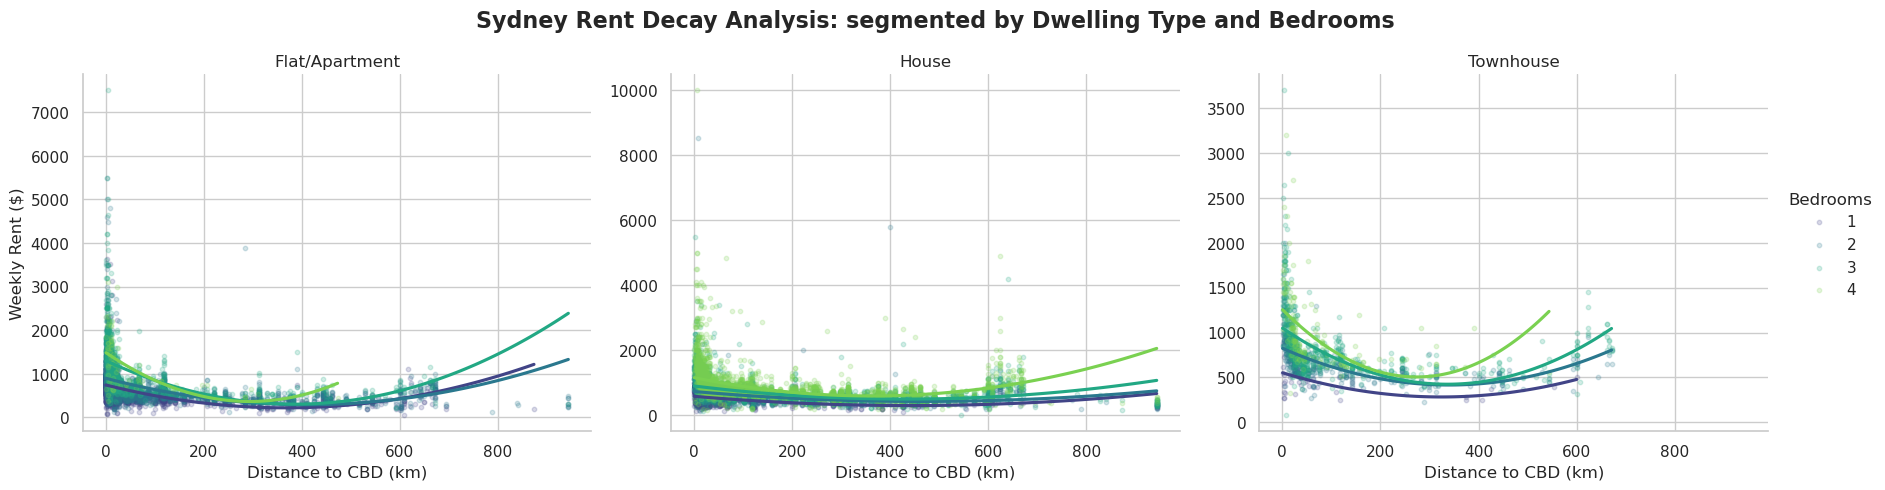


 [Segmented Market Snapshot - Average Rent by Type & Distance]


Bedrooms,1,2,3,4
Dwelling_Full_Name,,,,
Flat/Apartment,680.96,801.45,1133.03,1209.60
House,499.11,621.75,724.09,918.95
Townhouse,475.57,671.37,846.22,1006.47


In [14]:

# Sydney Housing Project - V5.2 Segmented Spatial Analysis (Robust Fix)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import radians, cos, sin, asin, sqrt

# 1. Haversine formula
def haversine(lat1, lon1, lat2, lon2):
    R = 6372.8 
    dLat = radians(lat2 - lat1)
    dLon = radians(lon2 - lon1)
    lat1, lat2 = radians(lat1), radians(lat2)
    a = sin(dLat / 2)**2 + cos(lat1) * cos(lat2) * sin(dLon / 2)**2
    return R * 2 * asin(sqrt(a))

CENTRAL_LAT, CENTRAL_LON = -33.8829, 151.2063

print(" Step 1: Merging Geolocation data...")
url = "https://raw.githubusercontent.com/matthewproctor/australianpostcodes/master/australian_postcodes.csv"
df_coords = pd.read_csv(url)[['postcode', 'lat', 'long']].drop_duplicates(subset=['postcode'])
df_coords.rename(columns={'postcode': 'Postcode', 'lat': 'Lat', 'long': 'Lon'}, inplace=True)

#  DEFENSIVE FIX: Resolve issues with Lat_x and Lat_y conflicts caused by repetitive merging.
if 'Lat' in df_clean.columns:
    df_clean = df_clean.drop(columns=['Lat', 'Lon'])

# Merge with the main cleaned dataset
df_clean['Postcode'] = pd.to_numeric(df_clean['Postcode'], errors='coerce')
df_spatial = pd.merge(df_clean, df_coords, on='Postcode', how='inner')

print(" Step 2: Calculating precise distances...")
df_spatial['Distance_to_CBD'] = df_spatial.apply(
    lambda row: haversine(row['Lat'], row['Lon'], CENTRAL_LAT, CENTRAL_LON), axis=1
)

print(" Step 3: Generating Multi-Facet Comparison Chart...")

# Filtering: To keep the chart clean, we focus on common bedroom counts (1-4)
# And primary residential types (F, H, T)
plot_df = df_spatial[
    (df_spatial['Bedrooms'].isin([1, 2, 3, 4])) & 
    (df_spatial['Dwelling Type'].isin(['F', 'H', 'T']))
].copy()

# Map abbreviations to full names for better readability in the report
type_map = {'F': 'Flat/Apartment', 'H': 'House', 'T': 'Townhouse'}
plot_df['Dwelling_Full_Name'] = plot_df['Dwelling Type'].map(type_map)

# Set visual style
sns.set_theme(style="whitegrid")

# Create a FacetGrid: columns are dwelling types
g = sns.FacetGrid(plot_df, col="Dwelling_Full_Name", hue="Bedrooms", 
                  height=5, aspect=1.2, palette="viridis", sharey=False)

# Map the regression plots to each grid
g.map(sns.regplot, "Distance_to_CBD", "Weekly Rent", 
      scatter_kws={'alpha':0.2, 's':10}, order=2, ci=None)

# Formatting the charts
g.add_legend(title="Bedrooms")
g.set_axis_labels("Distance to CBD (km)", "Weekly Rent ($)")
g.set_titles(col_template="{col_name}")

plt.subplots_adjust(top=0.85)
g.fig.suptitle('Sydney Rent Decay Analysis: segmented by Dwelling Type and Bedrooms', 
               fontsize=16, fontweight='bold')

plt.show()

# 💡 Step 4: Print Insight Table
print("\n [Segmented Market Snapshot - Average Rent by Type & Distance]")
summary = plot_df.groupby(['Dwelling_Full_Name', 'Bedrooms'])['Weekly Rent'].mean().unstack().round(2)
display(summary)

In [15]:

# Sydney Housing Project - Inspection: Dwelling Type Counts

print(" Checking all unique Dwelling Type abbreviations in the dataset...")

# 1. Get the counts of each unique abbreviation
type_counts = df['Dwelling Type'].value_counts()

# 2. Get the percentage for each type (to see which ones are dominant)
type_percentages = df['Dwelling Type'].value_counts(normalize=True) * 100

# 3. Combine them into a clean summary table
type_summary = pd.DataFrame({
    'Count': type_counts,
    'Percentage (%)': type_percentages.round(2)
})

print("\nSummary of Dwelling Types found:")
display(type_summary)

# 4. Critical Logic: Check if we have enough data for each type
print("\nSuggested Specialist Models:")
for code in type_summary.index:
    count = type_summary.loc[code, 'Count']
    if count > 100:
        print(f" Type '{code}': Strong candidate for a specialist model.")
    elif count > 20:
        print(f" Type '{code}': Small sample size, training might be unstable.")
    else:
        print(f" Type '{code}': Too few samples, suggest merging or dropping.")

 Checking all unique Dwelling Type abbreviations in the dataset...

Summary of Dwelling Types found:


,Count,Percentage (%)
Dwelling Type,,
F,12356,43.71
H,10867,38.44
O,2137,7.56
U,1669,5.90
T,1237,4.38
I,1,0.00
P,1,0.00
3,1,0.00



Suggested Specialist Models:
 Type 'F': Strong candidate for a specialist model.
 Type 'H': Strong candidate for a specialist model.
 Type 'O': Strong candidate for a specialist model.
 Type 'U': Strong candidate for a specialist model.
 Type 'T': Strong candidate for a specialist model.
 Type 'I': Too few samples, suggest merging or dropping.
 Type 'P': Too few samples, suggest merging or dropping.
 Type '3': Too few samples, suggest merging or dropping.


In [26]:

# Sydney Housing Project - V6.0 Spatial & Premium Enrichment
print("Step 1: Loading Cleaned POI Data...")
# Loading standardized datasets prepared in previous steps
df_stations = pd.read_csv('cleaned_stations.csv')
df_markets = pd.read_csv('cleaned_supermarkets.csv')
df_schools = pd.read_csv('cleaned_schools.csv')

# 1.1 Extract unique postcode coordinates to avoid redundant calculations
# Lat/Lon values were merged in V5.2 based on postcode centroids
unique_postcodes = df_spatial[['Postcode', 'Lat', 'Lon']].drop_duplicates().copy()

# 2. Vectorized Distance Calculation Logic
# Calculates the minimum distance from each postcode centroid to the nearest amenity
def get_min_dist(p_lat, p_lon, poi_df):
    # Apply haversine formula across all POIs and select the minimum distance
    # Rationale: Closest amenity has the highest impact on local rent
    dists = [haversine(p_lat, p_lon, row['Lat'], row['Lon']) for _, row in poi_df.iterrows()]
    return min(dists)

print("Step 2: Calculating Spatial Amenity Scores...")
# Generating proximity features for each postcode
unique_postcodes['Dist_to_Station'] = unique_postcodes.apply(lambda x: get_min_dist(x['Lat'], x['Lon'], df_stations), axis=1)
unique_postcodes['Dist_to_Market'] = unique_postcodes.apply(lambda x: get_min_dist(x['Lat'], x['Lon'], df_markets), axis=1)
unique_postcodes['Dist_to_School'] = unique_postcodes.apply(lambda x: get_min_dist(x['Lat'], x['Lon'], df_schools), axis=1)

# 3. Step 3: Identify 'Premium Zones' (The Rich Area Filter)
# Determines the rent index by comparing actual rent to the group mean of the same type and bedroom count
print("Step 3: Tagging Premium Postcodes...")

# Calculate the mean rent per category to isolate location premium from property size
df_spatial['Group_Mean'] = df_spatial.groupby(['Dwelling Type', 'Bedrooms'])['Weekly Rent'].transform('mean')

# Price_Index > 1.0 means the property is more expensive than the average for its size/type
df_spatial['Price_Index'] = df_spatial['Weekly Rent'] / df_spatial['Group_Mean']

# Define 'Premium Area' if the average Price Index of a postcode exceeds 1.2 (20% premium)
premium_index = df_spatial.groupby('Postcode')['Price_Index'].mean()
premium_list = premium_index[premium_index > 1.2].index
unique_postcodes['Is_Premium_Area'] = unique_postcodes['Postcode'].isin(premium_list).astype(int)

# 4. Merge results back to the primary spatial dataframe
# This creates the final feature matrix for the enhanced expert models
df_v6 = pd.merge(
    df_spatial, 
    unique_postcodes[['Postcode', 'Dist_to_Station', 'Dist_to_Market', 'Dist_to_School', 'Is_Premium_Area']], 
    on='Postcode', 
    how='left'
)

print("V6.0 Dataset Ready with Spatial Features and Premium Tags!")

Step 1: Loading Cleaned POI Data...
Step 2: Calculating Spatial Amenity Scores...
Step 3: Tagging Premium Postcodes...
V6.0 Dataset Ready with Spatial Features and Premium Tags!


In [29]:
# Print out the postcodes marked as Premium and their average premium multiple.
premium_summary = df_spatial.groupby('Postcode')['Price_Index'].mean().sort_values(ascending=False)
print("Top 10 Premium Postcodes (Identified by Machine):")
print(premium_summary.head(10))

# Check: See if it includes classic posh areas like 2023 (Bellevue Hill), 2030 (Vaucluse), 2088 (Mosman).

Top 10 Premium Postcodes (Identified by Machine):
Postcode
2092    2.067196
2104    2.027839
2030    2.024794
2108    1.958277
2063    1.888460
2024    1.803347
2000    1.759359
2028    1.735094
2206    1.675785
2110    1.651583
Name: Price_Index, dtype: float64


In [33]:
# Specialist Training V2.1 - Pruned Random Forest

from clearml import Task
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Close the previous task to avoid session conflicts
if Task.current_task():
    Task.current_task().close()

# Initialize a new task for the pruned experiment
task = Task.init(project_name="Sydney_Housing_Project", task_name="V2.1_Pruned_RF_Expert")

# Features from V6.0
enhanced_features = [
    'Bedrooms', 'Distance_to_CBD', 
    'Dist_to_Station', 'Dist_to_Market', 'Dist_to_School', 
    'Is_Premium_Area'
]

# Filtering for the Apartment expert
expert_code = 'F'
expert_data = df_v6[df_v6['Dwelling Type'] == expert_code].dropna(subset=enhanced_features + ['Weekly Rent'])

X = expert_data[enhanced_features]
y = expert_data['Weekly Rent']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Implementation of the 'Denoised' Random Forest
# We set max_depth and min_samples_leaf to force generalization
rf_pruned = RandomForestRegressor(
    n_estimators=150,        # Slightly more trees for stability
    max_depth=7,             # Prevents the tree from drilling down into single-property outliers
    min_samples_leaf=15,     # Each prediction must represent the average of at least 15 properties
    max_features='sqrt',     # Forces trees to look at different feature combinations
    random_state=42,
    n_jobs=-1
)

rf_pruned.fit(X_train, y_train)

# Evaluation
train_r2 = rf_pruned.score(X_train, y_train)
test_r2 = rf_pruned.score(X_test, y_test)

print(f"Pruned Training R2: {train_r2:.4f}")
print(f"Pruned Test R2: {test_r2:.4f}")
print(f"Gap (Overfitting measure): {abs(train_r2 - test_r2):.4f}")

# Log scalars to ClearML for comparison
task.get_logger().report_scalar(title="Performance", series="Training R2", value=train_r2, iteration=1)
task.get_logger().report_scalar(title="Performance", series="Test R2", value=test_r2, iteration=1)

ClearML Task: created new task id=84949eefffae47c3abd82a2d7efadb3b
ClearML results page: https://app.clear.ml/projects/63f62254946d42f8aae80879eb21f60c/experiments/84949eefffae47c3abd82a2d7efadb3b/output/log
Pruned Training R2: 0.5844
Pruned Test R2: 0.5586
Gap (Overfitting measure): 0.0257


In [32]:
# Check which features the model actually values
importances = pd.DataFrame({
    'Feature': enhanced_features,
    'Importance': rf_expert.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n Feature Importance Rankings:")
print(importances)

# Check for Overfitting: Compare Train vs Test score
train_r2 = rf_expert.score(X_train, y_train)
print(f"\n Training R2: {train_r2:.4f}")
print(f" Test R2: {new_r2:.4f}")


 Feature Importance Rankings:
           Feature  Importance
0         Bedrooms    0.322306
5  Is_Premium_Area    0.290889
1  Distance_to_CBD    0.226589
2  Dist_to_Station    0.065515
4   Dist_to_School    0.049398
3   Dist_to_Market    0.045304

 Training R2: 0.6636
 Test R2: 0.5597


In [34]:
def sydney_postcode_analyzer(postcode):
    # 1. Extract the postcode's features (distance, density, premium label) from df_v6.
    features = df_v6[df_v6['Postcode'] == postcode].iloc[0]
    
    # 2. Right, get ready to chuck in the data (reckon we're sussing out 2-bedder apartments).
    input_data = pd.DataFrame([{
        'Bedrooms': 2,
        'Distance_to_CBD': features['Distance_to_CBD'],
        'Dist_to_Station': features['Dist_to_Station'],
        'Dist_to_Market': features['Dist_to_Market'],
        'Dist_to_School': features['Dist_to_School'],
        'Is_Premium_Area': features['Is_Premium_Area']
    }])
    
    # 3. Get your expert model talkin'.
    predicted_price = rf_pruned.predict(input_data)[0]
    
    return f"Postcode {postcode} Analysis: Suggested Rent for 2-bed Apartment is ${predicted_price:.2f}"

# test
print(sydney_postcode_analyzer(2205))

Postcode 2205 Analysis: Suggested Rent for 2-bed Apartment is $853.61


In [35]:
# Sydney Housing Project - Demo V1.0 Postcode Analyzer


from sklearn.metrics import mean_absolute_error

# 1. First, we calculate the 'Logic Buffer' (MAE) from your trained model
y_pred_test = rf_pruned.predict(X_test)
logic_mae = mean_absolute_error(y_test, y_pred_test)

def get_postcode_analysis(postcode, bedrooms=2):
    # Search for the postcode in our enriched V6.0 dataset
    if postcode not in df_v6['Postcode'].values:
        print(f"Error: Postcode {postcode} not found in Sydney dataset.")
        return

    # Extract geographic DNA of the postcode
    geo = df_v6[df_v6['Postcode'] == postcode].iloc[0]
    
    # Prepare input for the Random Forest
    input_data = pd.DataFrame([{
        'Bedrooms': bedrooms,
        'Distance_to_CBD': geo['Distance_to_CBD'],
        'Dist_to_Station': geo['Dist_to_Station'],
        'Dist_to_Market': geo['Dist_to_Market'],
        'Dist_to_School': geo['Dist_to_School'],
        'Is_Premium_Area': geo['Is_Premium_Area']
    }])
    
    # Predict the base price
    base_price = rf_pruned.predict(input_data)[0]
    
    # Define the reasonable range using MAE
    lower_bound = base_price - logic_mae
    upper_bound = base_price + logic_mae

    # Optional: Calculate a simple 'Convenience Score' (0-10) for the report
    # Logic: Closer to station/market = higher score
    conv_score = 10 - (min(geo['Dist_to_Station'], 5) * 1) - (min(geo['Dist_to_Market'], 5) * 0.5)

    # ------------------ OUTPUT REPORT ------------------
    print(f"{'='*45}")
    print(f" SYDNEY RENT ANALYSIS: POSTCODE {postcode}")
    print(f"{'='*45}")
    print(f" Target: {bedrooms} Bedroom Apartment")
    print(f" Estimated Geographic Rent: ${base_price:.2f}/wk")
    print(f" Reasonable Market Range:  ${lower_bound:.0f} - ${upper_bound:.0f}/wk")
    print(f"{'-'*45}")
    print(f" AREA INSIGHTS:")
    print(f" > Location Class: {'PREMIUM' if geo['Is_Premium_Area'] == 1 else 'STANDARD'}")
    print(f" > Convenience Score: {max(0, conv_score):.1f}/10")
    print(f" > Closest Station: {geo['Dist_to_Station']:.2f} km")
    print(f" > CBD Proximity: {geo['Distance_to_CBD']:.2f} km")
    print(f"{'='*45}\n")

# Try it out!
get_postcode_analysis(2205)
get_postcode_analysis(2000) # Sydney CBD

 SYDNEY RENT ANALYSIS: POSTCODE 2205
 Target: 2 Bedroom Apartment
 Estimated Geographic Rent: $853.61/wk
 Reasonable Market Range:  $712 - $995/wk
---------------------------------------------
 AREA INSIGHTS:
 > Location Class: STANDARD
 > Convenience Score: 9.4/10
 > Closest Station: 0.14 km
 > CBD Proximity: 8.12 km

 SYDNEY RENT ANALYSIS: POSTCODE 2000
 Target: 2 Bedroom Apartment
 Estimated Geographic Rent: $1536.36/wk
 Reasonable Market Range:  $1395 - $1678/wk
---------------------------------------------
 AREA INSIGHTS:
 > Location Class: PREMIUM
 > Convenience Score: 9.0/10
 > Closest Station: 0.72 km
 > CBD Proximity: 2.53 km



In [42]:
# ==========================================
# Sydney Housing Project - V1.1 Smart Suburb Search & ClearML Tracking
# ==========================================

from clearml import Task
import pandas as pd

# 1. Ensure ClearML connection is active
# We use the current task to log these specific user inquiries
current_task = Task.current_task()
if not current_task:
    # If no task is running, initialize a dedicated monitor task
    current_task = Task.init(project_name="Sydney_Housing_Project", task_name="V1.1_User_Inquiry_Monitor")

# 2. Setup the Suburb-to-Postcode Dictionary
# Re-loading the mapping file to ensure we have 'locality' (Suburb Name)
postcode_url = "https://raw.githubusercontent.com/matthewproctor/australianpostcodes/master/australian_postcodes.csv"
df_lookup = pd.read_csv(postcode_url)[['postcode', 'locality', 'state']]
df_lookup = df_lookup[df_lookup['state'] == 'NSW'] # Only focus on NSW

def get_rent_analysis_by_name(suburb_name, bedrooms=2):
    suburb_name = suburb_name.strip().upper()
    
    # --- Part A: Retrieve all possible postcodes for the given suburb ---
    matches = df_lookup[df_lookup['locality'] == suburb_name]
    
    if matches.empty:
        print(f"[Error] Suburb '{suburb_name}' not found in NSW database.")
        return

    # Convert all matched postcodes into a list
    possible_postcodes = matches['postcode'].astype(int).tolist()
    
    # --- Part B: Intelligent Filtering (Core Fix) ---
    # Filter out PO Box postcodes; keep only those existing in our Sydney rental dataset
    valid_postcodes = [pc for pc in possible_postcodes if pc in df_v6['Postcode'].values]
    
    if not valid_postcodes:
        print(f"[Warning] Found postcodes {possible_postcodes} for {suburb_name}, but no rental data exists for them in our Sydney Dataset.")
        return
        
    # Extract the first valid residential postcode
    postcode = valid_postcodes[0]
    
    # --- Part C: ClearML Logging ---
    current_task.get_logger().report_text(f"User Inquiry: Suburb={suburb_name}, True Postcode={postcode}, Beds={bedrooms}")
    
    # --- Part D: Prediction Logic ---
    geo = df_v6[df_v6['Postcode'] == postcode].iloc[0]
    input_data = pd.DataFrame([{
        'Bedrooms': bedrooms,
        'Distance_to_CBD': geo['Distance_to_CBD'],
        'Dist_to_Station': geo['Dist_to_Station'],
        'Dist_to_Market': geo['Dist_to_Market'],
        'Dist_to_School': geo['Dist_to_School'],
        'Is_Premium_Area': geo['Is_Premium_Area']
    }])
    
    base_price = rf_pruned.predict(input_data)[0]
    
    current_task.get_logger().report_scalar(
        title="Prediction Monitor", 
        series=f"Rent_{suburb_name}", 
        value=base_price, 
        iteration=postcode
    )

    # --- Part E: Result Output ---
    print(f"\n{'='*45}")
    print(f"ANALYSIS FOR: {suburb_name} (Resolved Postcode: {postcode})")
    print(f"{'='*45}")
    print(f" Target: {bedrooms} Bedroom Apartment")
    print(f" Suggested Rent: ${base_price:.2f}/wk")
    print(f" Reasonable Range: ${base_price - logic_mae:.0f} - ${base_price + logic_mae:.0f}/wk")
    print(f"{'-'*45}")
    print(f" Area Stats: CBD {geo['Distance_to_CBD']:.1f}km | Station {geo['Dist_to_Station']:.2f}km")
    print(f"{'='*45}\n")


# ==========================================
# Interactive Query Terminal 
# ==========================================
print("\n" + "="*50)
print(" Welcome to the Sydney Rent Analysis System (type 'quit' to exit)")
print("="*50)

while True:
    # 1. Prompt user for input
    user_input = input("Enter a Sydney suburb to analyze (e.g., Waterloo): ")
    
    # 2. Exit loop if user types 'quit'
    if user_input.strip().lower() == 'quit':
        print("System exited.")
        break
        
    # 3. Skip empty inputs
    if not user_input.strip():
        continue
        
    # 4. Pass the input to the prediction function
    get_rent_analysis_by_name(user_input, bedrooms=2)


 Welcome to the Sydney Rent Analysis System (type 'quit' to exit)


Enter a Sydney suburb to analyze (e.g., Waterloo):  burwood


User Inquiry: Suburb=BURWOOD, True Postcode=2134, Beds=2

ANALYSIS FOR: BURWOOD (Resolved Postcode: 2134)
 Target: 2 Bedroom Apartment
 Suggested Rent: $823.38/wk
 Reasonable Range: $682 - $965/wk
---------------------------------------------
 Area Stats: CBD 9.7km | Station 0.39km



KeyboardInterrupt: Interrupted by user

In [43]:
# Export the "Brain": Model Serialization and Feature Extraction
import joblib
import pandas as pd

# 1. Export the trained Random Forest model (The core logic brain)
# .pkl (Pickle) is Python's native format for saving complex objects
joblib.dump(rf_pruned, 'sydney_rf_model_v1.pkl')
print("[Success] Model logic saved -> sydney_rf_model_v1.pkl")

# 2. Export the error metric (Used to calculate the reasonable price range)
joblib.dump(logic_mae, 'sydney_model_mae.pkl')
print("[Success] Error margin saved -> sydney_model_mae.pkl")

# 3. Extract and save the clean "Postcode Geographic Feature Database" 
# This represents the fundamental spatial data the model relies on.
# We only extract location data and use drop_duplicates() to remove 
# tens of thousands of redundant rows, drastically reducing file size.
postcode_db = df_v6[['Postcode', 'Distance_to_CBD', 'Dist_to_Station', 
                     'Dist_to_Market', 'Dist_to_School', 'Is_Premium_Area']].drop_duplicates()

postcode_db.to_csv('postcode_features.csv', index=False)
print("[Success] Postcode feature database saved -> postcode_features.csv")

print("\n[Complete] Packaging finished! You can now deploy these three files to your backend server.")

[Success] Model logic saved -> sydney_rf_model_v1.pkl
[Success] Error margin saved -> sydney_model_mae.pkl
[Success] Postcode feature database saved -> postcode_features.csv

[Complete] Packaging finished! You can now deploy these three files to your backend server.
